# Prediction Market Accuracy

This notebook evaluates whether liquid binary prediction markets from Polymarket and Kalshi produced probabilities that lined up with eventual outcomes. The scored sample is limited to resolved sports and elections markets with at least `$100,000` in volume, and each forecast is defined as the last non-trivial pre-resolution YES probability rather than the terminal settlement price.

The goal is not just to compute a Brier score, but to answer the more useful analytical question: do these markets beat simple baselines, and what market characteristics are associated with better accuracy?

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

from src.accuracy import (
    add_baseline_columns,
    baseline_comparison_table,
    calibration_table,
    metric_ci_summary,
    metric_summary,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

clean_dir = ROOT / 'data' / 'cleaned'
df = pd.read_csv(clean_dir / 'accuracy_markets.csv')
scored = add_baseline_columns(df)
platform_ci = metric_ci_summary(scored, ['platform'])
baseline_overall = pd.concat([
    baseline_comparison_table(scored, 'baseline_prob_50', 'always_50'),
    baseline_comparison_table(scored, 'baseline_prob_category_rate', 'category_base_rate_in_sample'),
], ignore_index=True)
baseline_by_platform = pd.concat([
    baseline_comparison_table(scored, 'baseline_prob_50', 'always_50', ['platform']),
    baseline_comparison_table(scored, 'baseline_prob_category_rate', 'category_base_rate_in_sample', ['platform']),
], ignore_index=True)


## Dataset Checks

These checks make sure the notebook is evaluating the intended MVP slice before interpreting any results. They also make the sample restrictions explicit for a reader who jumps straight to the notebook.

In [2]:
assert scored['category'].notna().all()
assert set(scored['resolution']).issubset({'YES', 'NO'})
assert scored['volume'].ge(100_000).all()
assert scored['forecast_prob'].between(0, 1).all()

scored[['platform', 'category']].value_counts().rename('markets').reset_index()

,platform,category,markets
0,kalshi,sports,394
1,polymarket,sports,316
2,kalshi,unclassified,171
3,kalshi,crypto,119
4,kalshi,commodities,42
5,polymarket,elections,35
6,polymarket,unclassified,30
7,polymarket,economics,9
8,polymarket,geopolitics,7
9,polymarket,politics,7


## Top-Line Accuracy

The headline result is that the scored sample has an overall Brier score of about `0.119`, which is meaningfully better than an uninformed coin-flip forecast but still far from perfect. Polymarket posts the lower raw Brier score in this sample, though that comparison should be read alongside the methodological caveat that Kalshi rows are currently snapshot-fallback heavy.

The category split matters a lot. Elections look dramatically easier than sports in this dataset, but the elections sample is small enough that it should be treated as a suggestive pattern rather than a firm platform-level conclusion.

In [3]:
overall = metric_summary(scored)
by_platform = metric_summary(scored, ['platform'])
by_category = metric_summary(scored, ['category'])
by_platform_category = metric_summary(scored, ['platform', 'category'])

display(overall)
display(by_platform)
display(by_category)

,group,n,brier,log_loss,avg_forecast,observed_yes_rate,median_days_to_resolution,median_volume
0,overall,1133,0.1067,0.3255,0.3890,0.3592,3.3433,287739.8900


,platform,n,brier,log_loss,avg_forecast,observed_yes_rate,median_days_to_resolution,median_volume
0,kalshi,729,0.1025,0.3168,0.4040,0.3717,1.6981,192200.3500
1,polymarket,404,0.1143,0.3414,0.3620,0.3366,9.2054,763810.4879


,category,n,brier,log_loss,avg_forecast,observed_yes_rate,median_days_to_resolution,median_volume
0,commodities,42,0.0334,0.1411,0.2890,0.1905,1.0690,170301.0000
1,crypto,119,0.0278,0.1087,0.5092,0.4958,NaN,139412.0000
2,culture,1,0.0025,0.0513,0.0500,0.0000,0.7354,1715060.0000
3,economics,9,0.0000,0.0027,0.1093,0.1111,55.0825,205962.1168
4,elections,36,0.0032,0.0334,0.1506,0.1389,37.0811,1881317.5346
5,finance,1,0.0225,0.1625,0.8500,1.0000,NaN,113441.7400
6,geopolitics,7,0.0008,0.0271,0.8361,0.8571,48.2867,5872191.7818
7,politics,7,0.0004,0.0102,0.1466,0.1429,4.3331,1381157.4622
8,sports,710,0.1456,0.4283,0.3849,0.3507,4.5720,451006.4733
9,unclassified,201,0.0633,0.2197,0.4008,0.3831,2.2807,237280.2600


## Baseline Comparison

This is the section that gives the Brier score context. The market forecasts beat both a naive `50%` baseline and an in-sample category base-rate baseline, which shows that the result is not just a byproduct of many markets resolving NO.

The in-sample category base-rate benchmark is useful as a descriptive comparator, but it is not an ex-ante trading strategy. It uses the realized YES rate within each category, so it should be interpreted as a tougher hindsight benchmark rather than something a trader could have known ahead of time.

In [4]:
baseline_display = baseline_overall.copy()
for col in baseline_display.columns:
    if col.endswith('_pct'):
        baseline_display[col] = baseline_display[col].map(lambda x: f'{x:.1%}')

display(baseline_display)

,group,n,baseline,brier_market,brier_baseline,brier_improvement,brier_improvement_pct,log_loss_market,log_loss_baseline,log_loss_improvement,log_loss_improvement_pct
0,overall,1133,always_50,0.1067,0.2500,0.1433,57.3%,0.3255,0.6931,0.3676,53.0%
1,overall,1133,category_base_rate_in_sample,0.1067,0.2227,0.1159,52.1%,0.3255,0.6356,0.3100,48.8%


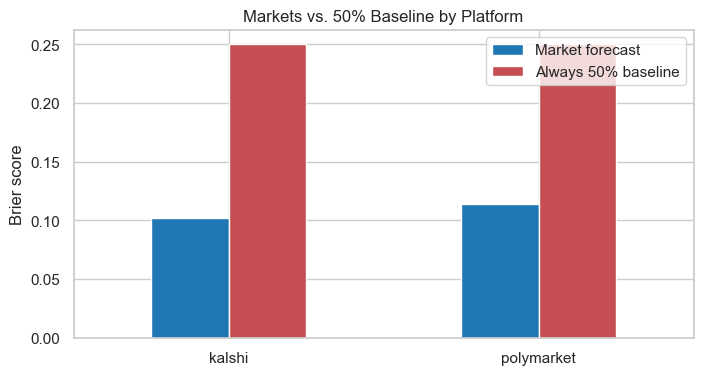

In [5]:
plot_baseline = baseline_by_platform[baseline_by_platform['baseline'] == 'always_50'].copy()
fig, ax = plt.subplots(figsize=(8, 4))
plot_baseline.plot(
    x='platform',
    y=['brier_market', 'brier_baseline'],
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#c44e52'],
)
ax.set_title('Markets vs. 50% Baseline by Platform')
ax.set_xlabel('')
ax.set_ylabel('Brier score')
ax.legend(['Market forecast', 'Always 50% baseline'])
plt.xticks(rotation=0)
plt.show()

## Uncertainty Around Platform Comparisons

Point estimates alone can overstate certainty, so the platform comparison should include uncertainty bands. The bootstrap intervals below suggest that both platforms are clearly better than a naive baseline, while the raw Polymarket advantage is modest enough that it should be discussed cautiously rather than framed as a decisive winner-take-all result.

This matters especially because the two platforms are not perfectly matched on forecast source quality, category mix, or time to resolution.

In [6]:
ci_display = platform_ci.copy()
for metric in ['brier', 'log_loss']:
    ci_display[f'{metric}_95_ci'] = ci_display.apply(
        lambda row: f"[{row[f'{metric}_ci_lower']:.3f}, {row[f'{metric}_ci_upper']:.3f}]",
        axis=1,
    )

display(ci_display[['platform', 'n', 'brier', 'brier_95_ci', 'log_loss', 'log_loss_95_ci']])

,platform,n,brier,brier_95_ci,log_loss,log_loss_95_ci
0,kalshi,729,0.1025,"[0.090, 0.115]",0.3168,"[0.285, 0.349]"
1,polymarket,404,0.1143,"[0.100, 0.129]",0.3414,"[0.307, 0.379]"


## Accuracy by Platform and Category

The platform-by-category view shows why a single overall metric can hide structure in the data. In the current sample, both platforms look much stronger in elections than in sports, and the platform gap is mostly a sports-story rather than a universal ranking across every slice.

That also reinforces the main caution for presentation: this project is strongest when it emphasizes careful evaluation and caveats, not when it over-claims a simple leaderboard.

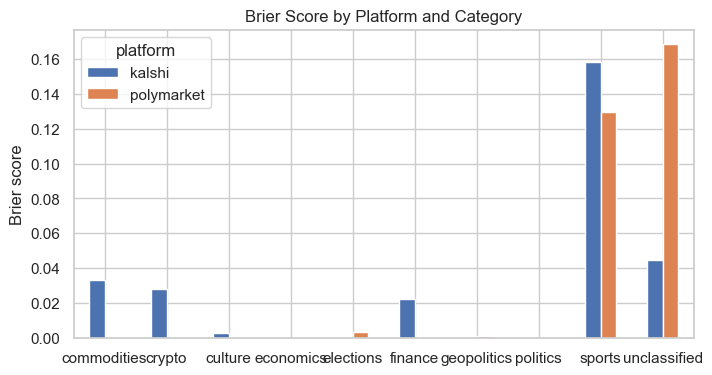

In [7]:
plot_df = by_platform_category.copy()
ax = plot_df.pivot(index='category', columns='platform', values='brier').plot(kind='bar', figsize=(8, 4))
ax.set_title('Brier Score by Platform and Category')
ax.set_ylabel('Brier score')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.show()

## Calibration

A calibrated market should land near the 45-degree line: buckets forecast around `70%` YES should resolve YES roughly `70%` of the time. In this sample the markets are directionally reasonable, but many mid-probability buckets sit below the diagonal, which means the market probabilities were often somewhat too optimistic about YES outcomes.

That pattern matches the overall sample imbalance, where the average forecast probability is higher than the realized YES rate. The largest miscalibration shows up in the middle of the range rather than at the extreme tails.

,probability_bin,n,avg_forecast,observed_yes_rate,brier,log_loss
0,"(-0.001, 0.1]",405,0.0319,0.0148,0.0146,0.0728
1,"(0.1, 0.2]",59,0.1578,0.1017,0.0892,0.3207
2,"(0.2, 0.3]",76,0.2586,0.2237,0.1711,0.5251
3,"(0.3, 0.4]",79,0.3553,0.2911,0.2137,0.6194
4,"(0.4, 0.5]",103,0.4541,0.3689,0.2390,0.6710
5,"(0.5, 0.6]",80,0.5560,0.4625,0.2555,0.7041
6,"(0.6, 0.7]",66,0.6476,0.6515,0.2310,0.6552
7,"(0.7, 0.8]",67,0.7417,0.6418,0.2349,0.6640
8,"(0.8, 0.9]",33,0.8473,0.8788,0.1088,0.3758
9,"(0.9, 1.0]",165,0.9645,1.0000,0.0016,0.0363


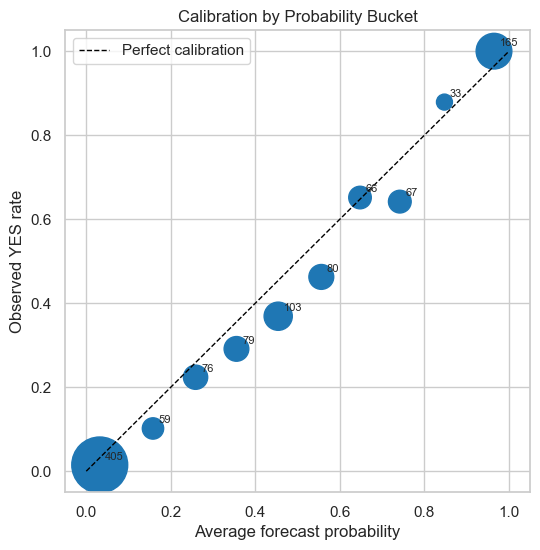

In [8]:
calibration = calibration_table(scored)
display(calibration)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1, label='Perfect calibration')
ax.scatter(calibration['avg_forecast'], calibration['observed_yes_rate'], s=calibration['n'] * 4, color='#1f77b4')
for _, row in calibration.iterrows():
    ax.annotate(str(int(row['n'])), (row['avg_forecast'], row['observed_yes_rate']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Average forecast probability')
ax.set_ylabel('Observed YES rate')
ax.set_title('Calibration by Probability Bucket')
ax.legend()
plt.show()

## Probability Buckets

The bucket table below makes the calibration picture easier to audit. The largest bucket is the near-zero range, which is reassuring because those markets mostly do resolve NO, but the middle buckets show a recurring gap where implied YES probabilities run ahead of realized YES outcomes.

This is a useful interview talking point because it shows the difference between discrimination and calibration: markets can rank outcomes sensibly while still being a little too aggressive in the middle of the probability distribution.

In [9]:
bucket_summary = calibration.copy()
bucket_summary['probability_bin'] = bucket_summary['probability_bin'].astype(str)
bucket_summary['calibration_gap'] = bucket_summary['observed_yes_rate'] - bucket_summary['avg_forecast']
bucket_summary

,probability_bin,n,avg_forecast,observed_yes_rate,brier,log_loss,calibration_gap
0,"(-0.001, 0.1]",405,0.0319,0.0148,0.0146,0.0728,-0.0171
1,"(0.1, 0.2]",59,0.1578,0.1017,0.0892,0.3207,-0.0561
2,"(0.2, 0.3]",76,0.2586,0.2237,0.1711,0.5251,-0.0349
3,"(0.3, 0.4]",79,0.3553,0.2911,0.2137,0.6194,-0.0642
4,"(0.4, 0.5]",103,0.4541,0.3689,0.2390,0.6710,-0.0851
5,"(0.5, 0.6]",80,0.5560,0.4625,0.2555,0.7041,-0.0935
6,"(0.6, 0.7]",66,0.6476,0.6515,0.2310,0.6552,0.0039
7,"(0.7, 0.8]",67,0.7417,0.6418,0.2349,0.6640,-0.0999
8,"(0.8, 0.9]",33,0.8473,0.8788,0.1088,0.3758,0.0315
9,"(0.9, 1.0]",165,0.9645,1.0000,0.0016,0.0363,0.0355


## Simple Regression on Forecast Error

To make this more than a descriptive dashboard, I fit a simple OLS model predicting market-level Brier score from `log(volume)`, `days_to_resolution`, platform, and category. This is an associational model rather than a causal claim, so the coefficients should be read as conditional correlations inside the current dataset.

Two patterns stand out in the current fit: higher-volume markets are associated with lower error, and longer-duration markets are also associated with lower error after controls. The platform coefficient flips relative to the raw average comparison, which is a nice reminder that the raw Polymarket advantage partly reflects differences in market mix rather than a clean platform effect.

In [10]:
regression_df = scored.dropna(subset=['days_to_resolution']).copy()
regression_df['log_volume'] = np.log1p(regression_df['volume'])

model = smf.ols(
    'brier ~ log_volume + days_to_resolution + C(platform) + C(category)',
    data=regression_df,
).fit(cov_type='HC3')

coef_table = model.summary2().tables[1]
display(coef_table)
print(f'Observations used in regression: {len(regression_df)}')

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,0.1322,0.0704,1.8775,0.0605,-0.0058,0.2703
C(platform)[T.polymarket],0.1373,0.0162,8.4815,0.0000,0.1055,0.1690
C(category)[T.culture],-0.0388,0.1253,-0.3096,0.7569,-0.2844,0.2068
C(category)[T.economics],-0.1574,0.0250,-6.2977,0.0000,-0.2064,-0.1084
C(category)[T.elections],-0.1424,0.0253,-5.6372,0.0000,-0.1920,-0.0929
C(category)[T.geopolitics],-0.1293,0.0291,-4.4483,0.0000,-0.1863,-0.0724
C(category)[T.politics],-0.1774,0.0252,-7.0364,0.0000,-0.2268,-0.1280
C(category)[T.sports],0.0021,0.0229,0.0907,0.9277,-0.0427,0.0469
C(category)[T.unclassified],-0.0059,0.0225,-0.2635,0.7921,-0.0500,0.0382
log_volume,-0.0063,0.0055,-1.1543,0.2484,-0.0170,0.0044


Observations used in regression: 645


## Conclusion

The strongest bottom-line takeaway is that these prediction markets are informative: they beat both a naive `50%` benchmark and an in-sample category base-rate benchmark by a wide margin. But a Brier score around `0.12` also means liquid markets are not perfectly efficient forecasting machines, especially in the noisier sports slice and in the middle-probability buckets where calibration slips.

If I were presenting this in an interview, I would frame the project as evidence of disciplined evaluation. The interesting story is not “markets are magic,” but rather “markets contain real forecasting signal, that signal varies by context, and careful baselines plus uncertainty estimates are necessary before drawing platform-level conclusions.”